In [1]:
# PROJECT  : Diabetes Patient Readmission Risk Analysis
# DATASET  : 130 US Hospitals | 1999-2008 | ~101,000 Patient Records
# GOAL     : Find what factors drive 30-day hospital readmissions in diabetic patients
# TOOLS    : Python, Pandas, Matplotlib, Seaborn, Scikit-learn
# AUTHOR   : [Your Name]


# SECTION 1 — IMPORT LIBRARIES

In [2]:
# SECTION 1 — IMPORT LIBRARIES


In [3]:

import pandas as pd                          # For loading and manipulating tabular data
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For creating charts and plots
import matplotlib.ticker as mtick            # For formatting axis labels (e.g., % signs)
import seaborn as sns                        # For beautiful statistical visualizations
import warnings                              # To suppress unnecessary warning messages
import os                                    # For file path handling

# Machine Learning imports
from sklearn.model_selection import train_test_split        # Split data into train/test sets
from sklearn.preprocessing import LabelEncoder              # Convert text categories to numbers
from sklearn.linear_model import LogisticRegression         # Our main ML model
from sklearn.ensemble import RandomForestClassifier         # Second ML model for comparison
from sklearn.metrics import (
    classification_report,                   # Precision, recall, F1 scores
    confusion_matrix,                        # Show correct vs wrong predictions
    roc_auc_score,                           # Model performance score (0.5 = random, 1.0 = perfect)
    roc_curve                                # Data to draw the ROC curve chart
)

warnings.filterwarnings('ignore')            # Hide warnings so output stays clean
plt.style.use('seaborn-v0_8-whitegrid')     # Apply a clean visual theme to all charts

# Create output folder to save all plots automatically
os.makedirs('plots', exist_ok=True)          # Creates a 'plots' folder if it doesn't exist

print("=" * 60)
print("   DIABETES READMISSION ANALYSIS — PROJECT STARTING")
print("=" * 60)




   DIABETES READMISSION ANALYSIS — PROJECT STARTING


# SECTION 2 — LOAD DATA

In [4]:
# SECTION 2 — LOAD DATA


In [5]:

print("\n[STEP 1] Loading datasets...")

# Load the main patient data
# na_values='?' → treats '?' in the CSV as NaN (missing), not the text '?'
df = pd.read_csv(
    'diabetic_data.csv',
    na_values='?'
)

# Load the ID mapping file (converts number codes → human-readable labels)
mapping_df = pd.read_csv('IDS_mapping.csv')

print(f"   ✓ Main dataset loaded     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   ✓ Mapping file loaded     : {mapping_df.shape[0]} rows")

# Quick sanity check — see the first 2 rows
print("\n   First 2 rows preview:")
print(df.head(2).to_string())





[STEP 1] Loading datasets...
   ✓ Main dataset loaded     : 101,766 rows × 50 columns
   ✓ Mapping file loaded     : 67 rows

   First 2 rows preview:
   encounter_id  patient_nbr       race  gender      age weight  admission_type_id  discharge_disposition_id  admission_source_id  time_in_hospital payer_code         medical_specialty  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  diag_1  diag_2 diag_3  number_diagnoses max_glu_serum A1Cresult metformin repaglinide nateglinide chlorpropamide glimepiride acetohexamide glipizide glyburide tolbutamide pioglitazone rosiglitazone acarbose miglitol troglitazone tolazamide examide citoglipton insulin glyburide-metformin glipizide-metformin glimepiride-pioglitazone metformin-rosiglitazone metformin-pioglitazone change diabetesMed readmitted
0       2278392      8222157  Caucasian  Female   [0-10)    NaN                  6                        25                    1               

# SECTION 3 — PARSE MAPPING

In [6]:
# SECTION 3 — PARSE THE MAPPING FILE


In [7]:
# The IDS_mapping.csv has 3 separate tables stacked vertically in one file.
# We need to manually split them into 3 dictionaries for admission_type,
# discharge_disposition, and admission_source.

print("\n[STEP 2] Parsing ID mapping tables...")

# Find where each section starts by looking for the header rows
# The file has 3 headers: admission_type_id, discharge_disposition_id, admission_source_id

admission_type_map     = {}
discharge_disp_map     = {}
admission_source_map   = {}

current_section = None

for _, row in mapping_df.iterrows():
    first_col = str(row.iloc[0]).strip()
    desc      = str(row.iloc[1]).strip() if not pd.isna(row.iloc[1]) else ''

    # Detect which section we're entering
    if first_col == 'admission_type_id':
        current_section = 'admission_type'
        continue
    elif first_col == 'discharge_disposition_id':
        current_section = 'discharge'
        continue
    elif first_col == 'admission_source_id':
        current_section = 'admission_source'
        continue

    # Skip blank rows and header repeat rows
    if first_col in ['', 'nan'] or desc in ['', 'nan']:
        continue

    try:
        key = int(float(first_col))            # Convert the ID number to integer
        if   current_section == 'admission_type':    admission_type_map[key]   = desc
        elif current_section == 'discharge':         discharge_disp_map[key]   = desc
        elif current_section == 'admission_source':  admission_source_map[key] = desc
    except:
        continue

print(f"   ✓ Admission type  entries : {len(admission_type_map)}")
print(f"   ✓ Discharge disp  entries : {len(discharge_disp_map)}")
print(f"   ✓ Admission source entries: {len(admission_source_map)}")





[STEP 2] Parsing ID mapping tables...
   ✓ Admission type  entries : 0
   ✓ Discharge disp  entries : 29
   ✓ Admission source entries: 24


# SECTION 4 — DATA EXPLORATION

In [8]:
# SECTION 4 — INITIAL DATA EXPLORATION


In [9]:

print("\n[STEP 3] Exploring raw data...")

# Count missing values in each column and show only those with missing data
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("\n   Columns with missing values:")
print(missing_report.to_string())

# Show the distribution of the target variable (what we're predicting)
print("\n   Target variable — 'readmitted' distribution:")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')





[STEP 3] Exploring raw data...

   Columns with missing values:
                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02

   Target variable — 'readmitted' distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.91%
>30    34.93%
<30    11.16%
Name: proportion, dtype: object


# SECTION 5 — DATA CLEANING

In [10]:
# SECTION 5 — DATA CLEANING


In [11]:

print("\n[STEP 4] Cleaning data...")

# ── 5.1 Drop columns that are too sparse or irrelevant ──────────────────────

# 'weight'     : 97% missing — useless for analysis, dropping it
# 'payer_code' : 52% missing and not clinically relevant to readmission
df.drop(columns=['weight', 'payer_code'], inplace=True)
print("   ✓ Dropped 'weight' (97% missing) and 'payer_code' (52% missing)")

# ── 5.2 Fill remaining missing values ───────────────────────────────────────

# 'medical_specialty': 53% missing, but the column is useful
# We fill with 'Missing' so it becomes its own category, not excluded
df['medical_specialty'].fillna('Missing', inplace=True)

# 'race': only 2% missing — fill with 'Unknown' to preserve all rows
df['race'].fillna('Unknown', inplace=True)

# 'diag_2' and 'diag_3' are secondary diagnoses — some patients just don't have them
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

print("   ✓ Filled missing values in medical_specialty, race, diag_2, diag_3")

# ── 5.3 Remove deaths and hospice discharges ─────────────────────────────────
# Patients who died (id=11) or went to hospice (13,14,19,20,21) can't be
# readmitted. Including them would bias our readmission analysis downward.

before = len(df)
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]
print(f"   ✓ Removed {before - len(df):,} expired/hospice patients")

# ── 5.4 Keep only one encounter per patient ──────────────────────────────────
# Some patients appear multiple times. To avoid data leakage and keep
# observations statistically independent, we keep only the FIRST visit.

before = len(df)
df = df.sort_values('encounter_id')           # Sort so 'first' = earliest encounter
df = df.drop_duplicates(subset='patient_nbr', keep='first')
print(f"   ✓ Removed {before - len(df):,} duplicate patient encounters (kept first visit only)")

# ── 5.5 Map coded IDs to readable labels ─────────────────────────────────────

df['admission_type_label']   = df['admission_type_id'].map(admission_type_map).fillna('Unknown')
df['discharge_label']        = df['discharge_disposition_id'].map(discharge_disp_map).fillna('Unknown')
df['admission_source_label'] = df['admission_source_id'].map(admission_source_map).fillna('Unknown')
print("   ✓ Mapped admission_type, discharge_disposition, admission_source IDs to labels")

# ── 5.6 Create the target variable ───────────────────────────────────────────
# Original column has 3 values: '<30', '>30', 'NO'
# We convert to binary: 1 = readmitted within 30 days, 0 = not (our prediction goal)

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(f"\n   ✓ Target variable created:")
print(f"      Readmitted within 30 days (1) : {df['readmitted_binary'].sum():,}  ({df['readmitted_binary'].mean()*100:.1f}%)")
print(f"      Not readmitted (0)            : {(df['readmitted_binary']==0).sum():,}  ({(1-df['readmitted_binary'].mean())*100:.1f}%)")

print(f"\n   ✓ Final clean dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")





[STEP 4] Cleaning data...
   ✓ Dropped 'weight' (97% missing) and 'payer_code' (52% missing)
   ✓ Filled missing values in medical_specialty, race, diag_2, diag_3
   ✓ Removed 2,423 expired/hospice patients
   ✓ Removed 29,353 duplicate patient encounters (kept first visit only)
   ✓ Mapped admission_type, discharge_disposition, admission_source IDs to labels

   ✓ Target variable created:
      Readmitted within 30 days (1) : 6,285  (9.0%)
      Not readmitted (0)            : 63,705  (91.0%)

   ✓ Final clean dataset size: 69,990 rows × 52 columns


# SECTION 6 — FEATURE ENGINEERING

In [12]:
# SECTION 6 — FEATURE ENGINEERING


In [13]:
# We create new columns derived from existing ones to make the analysis richer.

print("\n[STEP 5] Feature engineering...")

# ── 6.1 Map ICD-9 diagnosis codes to readable disease groups ──────────────────
# diag_1 column contains raw ICD-9 codes like '250.83', '276', 'V27' etc.
# We group them into 9 standard clinical categories.

def map_diagnosis(diag):
    """
    Convert an ICD-9 code string into a clinical diagnosis group name.
    V and E codes are external causes and coded specially — we convert
    them to 0 so the float() conversion doesn't fail.
    """
    try:
        code = float(str(diag).replace('V', '0').replace('E', '0'))
        if str(diag).startswith('250'):      return 'Diabetes'
        elif 390 <= code <= 459 or code == 785: return 'Circulatory'
        elif 460 <= code <= 519 or code == 786: return 'Respiratory'
        elif 520 <= code <= 579 or code == 787: return 'Digestive'
        elif 800 <= code <= 999:             return 'Injury'
        elif 710 <= code <= 739:             return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788: return 'Genitourinary'
        elif 140 <= code <= 239:             return 'Neoplasms'
        else:                                return 'Other'
    except:
        return 'Other'

df['diag_group'] = df['diag_1'].apply(map_diagnosis)
print("   ✓ Diagnosis groups created from ICD-9 codes")
print("     Distribution:", df['diag_group'].value_counts().to_dict())

# ── 6.2 Simplify age column to numeric midpoint ───────────────────────────────
# Age is stored as text ranges like '[50-60)'. We convert to midpoint number
# so it works in correlation and ML models.

age_map = {
    '[0-10)':10, '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45, '[50-60)':55, '[60-70)':65, '[70-80)':75,
    '[80-90)':85, '[90-100)':95
}
df['age_numeric'] = df['age'].map(age_map)
print("   ✓ Age ranges converted to numeric midpoints")

# ── 6.3 Simplify discharge label to binary ────────────────────────────────────
# 'Discharged to home' is a good outcome; everything else is more complex.
# This binary feature is easier for ML to learn from.

df['discharged_home'] = (df['discharge_label'] == 'Discharged to home').astype(int)
print("   ✓ Binary 'discharged_home' column created")

# ── 6.4 Total prior visits feature ───────────────────────────────────────────
# Patients who visited many times before are likely sicker = higher readmission risk
df['total_prior_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)
print("   ✓ 'total_prior_visits' feature created (outpatient + emergency + inpatient)")





[STEP 5] Feature engineering...
   ✓ Diagnosis groups created from ICD-9 codes
     Distribution: {'Circulatory': 21390, 'Other': 12133, 'Respiratory': 9491, 'Digestive': 6488, 'Diabetes': 5748, 'Injury': 4697, 'Musculoskeletal': 4064, 'Genitourinary': 3441, 'Neoplasms': 2538}
   ✓ Age ranges converted to numeric midpoints
   ✓ Binary 'discharged_home' column created
   ✓ 'total_prior_visits' feature created (outpatient + emergency + inpatient)


# SECTION 7 — EDA

In [28]:
# SECTION 7 — EXPLORATORY DATA ANALYSIS (EDA)


In [29]:
# EDA = understanding our data visually before any modeling.
# Each chart answers a specific business question.

print("\n[STEP 6] Creating EDA charts...")


[STEP 6] Creating EDA charts...


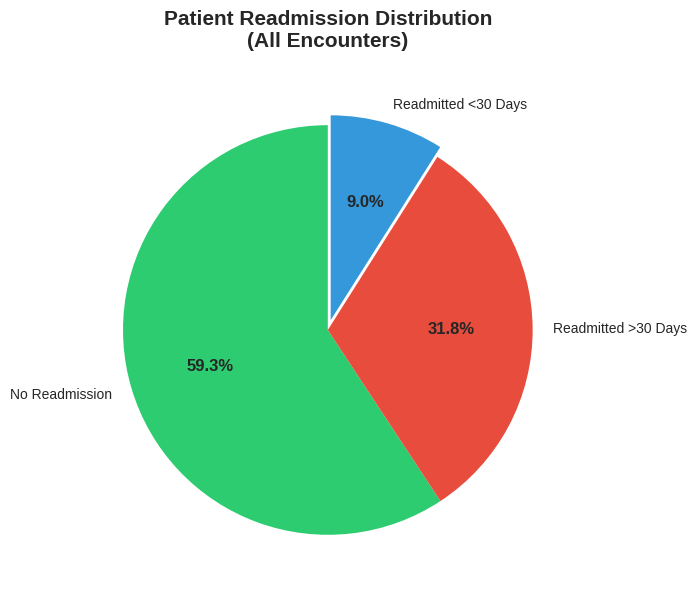

   ✓ Chart 1 saved: Overall readmission distribution


In [30]:
# ── CHART 1: Overall Readmission Distribution (Pie Chart) ─────────────────────
# Question: What percentage of patients are readmitted within 30 days?

fig, ax = plt.subplots(figsize=(7, 7))

readmit_counts = df['readmitted'].value_counts()    # Count each category
colors = ['#2ecc71', '#e74c3c', '#3498db']          # Green=No, Red=<30, Blue=>30

wedges, texts, autotexts = ax.pie(
    readmit_counts,
    labels=['No Readmission', 'Readmitted >30 Days', 'Readmitted <30 Days'],
    colors=colors,
    autopct='%1.1f%%',           # Show percentage on each slice
    startangle=90,               # Start first slice at top
    explode=(0, 0, 0.05)         # Slightly pull out the <30 slice to highlight it
)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Patient Readmission Distribution\n(All Encounters)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/01_readmission_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 1 saved: Overall readmission distribution")


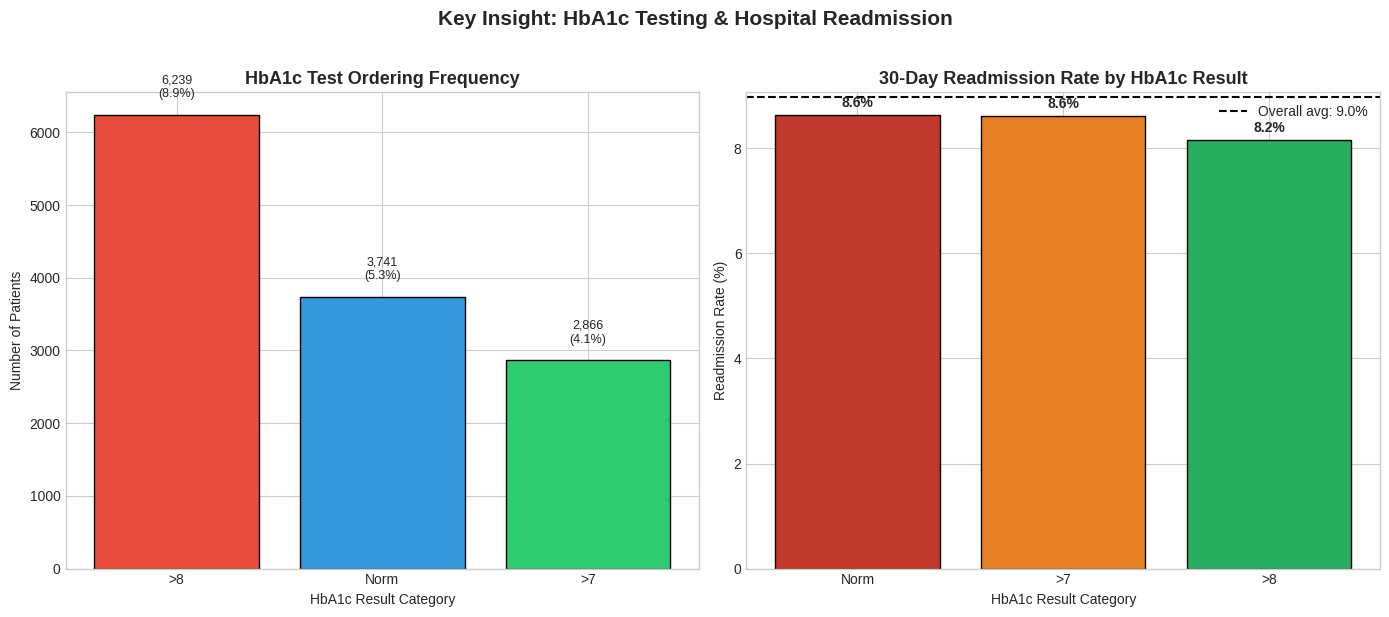

   ✓ Chart 2 saved: HbA1c vs readmission


In [31]:
# ── CHART 2: HbA1c Test vs Readmission Rate ───────────────────────────────────
# Question: Does ordering an HbA1c test reduce readmission?
# This is the CORE INSIGHT of this dataset per the research paper.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — how many patients got tested at all?
a1c_counts = df['A1Cresult'].value_counts()
axes[0].bar(a1c_counts.index, a1c_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'], edgecolor='black')
axes[0].set_title('HbA1c Test Ordering Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('HbA1c Result Category')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(a1c_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# Right plot — readmission rate per HbA1c group
a1c_readmit = df.groupby('A1Cresult')['readmitted_binary'].mean() * 100
a1c_readmit = a1c_readmit.sort_values(ascending=False)
bars = axes[1].bar(a1c_readmit.index, a1c_readmit.values,
                   color=['#c0392b', '#e67e22', '#27ae60', '#2980b9'], edgecolor='black')
axes[1].set_title('30-Day Readmission Rate by HbA1c Result', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HbA1c Result Category')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].axhline(y=df['readmitted_binary'].mean()*100, color='black',
                linestyle='--', linewidth=1.5, label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
axes[1].legend()
for bar, val in zip(bars, a1c_readmit.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Key Insight: HbA1c Testing & Hospital Readmission', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/02_hba1c_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 2 saved: HbA1c vs readmission")


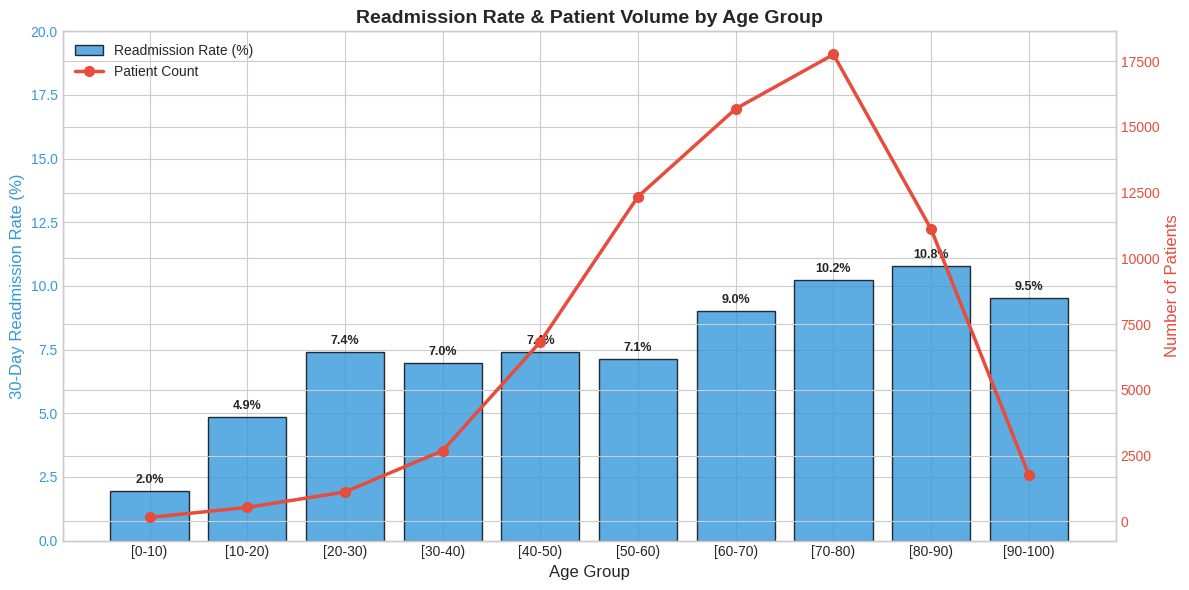

   ✓ Chart 3 saved: Readmission by age group


In [32]:
# ── CHART 3: Readmission Rate by Age Group ────────────────────────────────────
# Question: Are older patients more likely to be readmitted?

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = df.groupby('age')['readmitted_binary'].agg(['mean', 'count']).reindex(age_order)
age_readmit['mean_pct'] = age_readmit['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart = readmission rate (left axis)
bars = ax1.bar(age_readmit.index, age_readmit['mean_pct'],
               color='#3498db', alpha=0.8, edgecolor='black', label='Readmission Rate (%)')
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('30-Day Readmission Rate (%)', color='#3498db', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_ylim(0, 20)

# Line chart = patient count (right axis)
ax2 = ax1.twinx()                              # Create a second y-axis sharing the same x-axis
ax2.plot(age_readmit.index, age_readmit['count'], color='#e74c3c',
         marker='o', linewidth=2.5, markersize=7, label='Patient Count')
ax2.set_ylabel('Number of Patients', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Add value labels on bars
for bar, val in zip(bars, age_readmit['mean_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Readmission Rate & Patient Volume by Age Group', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('plots/03_readmission_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 3 saved: Readmission by age group")

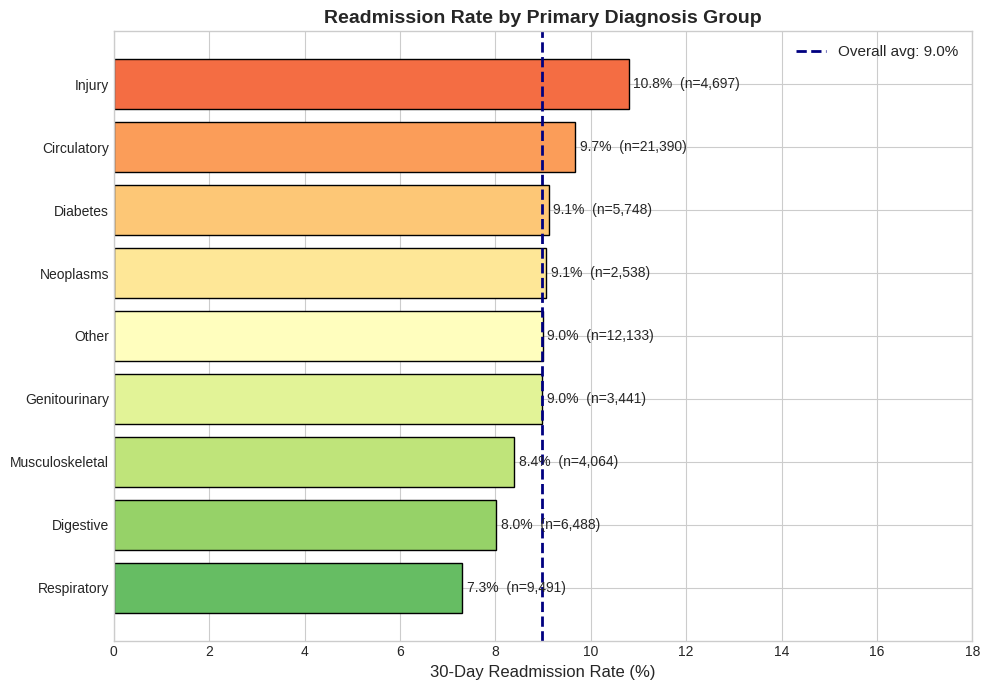

   ✓ Chart 4 saved: Readmission by diagnosis group


In [33]:
# ── CHART 4: Primary Diagnosis vs Readmission Rate ───────────────────────────
# Question: Which medical condition has the highest readmission rate?

diag_stats = df.groupby('diag_group').agg(
    readmission_rate=('readmitted_binary', 'mean'),
    patient_count=('readmitted_binary', 'count')
).reset_index()
diag_stats['readmission_rate_pct'] = diag_stats['readmission_rate'] * 100
diag_stats = diag_stats.sort_values('readmission_rate_pct', ascending=True)   # Sort for horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 7))
colors_diag = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(diag_stats)))  # Color gradient: green=low, red=high

bars = ax.barh(diag_stats['diag_group'], diag_stats['readmission_rate_pct'],
               color=colors_diag, edgecolor='black')

# Add value labels at end of each bar
for bar, val, count in zip(bars, diag_stats['readmission_rate_pct'], diag_stats['patient_count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (n={count:,})', va='center', fontsize=10)

ax.axvline(x=df['readmitted_binary'].mean()*100, color='navy',
           linestyle='--', linewidth=2, label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.set_xlabel('30-Day Readmission Rate (%)', fontsize=12)
ax.set_title('Readmission Rate by Primary Diagnosis Group', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 18)
plt.tight_layout()
plt.savefig('plots/04_readmission_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 4 saved: Readmission by diagnosis group")

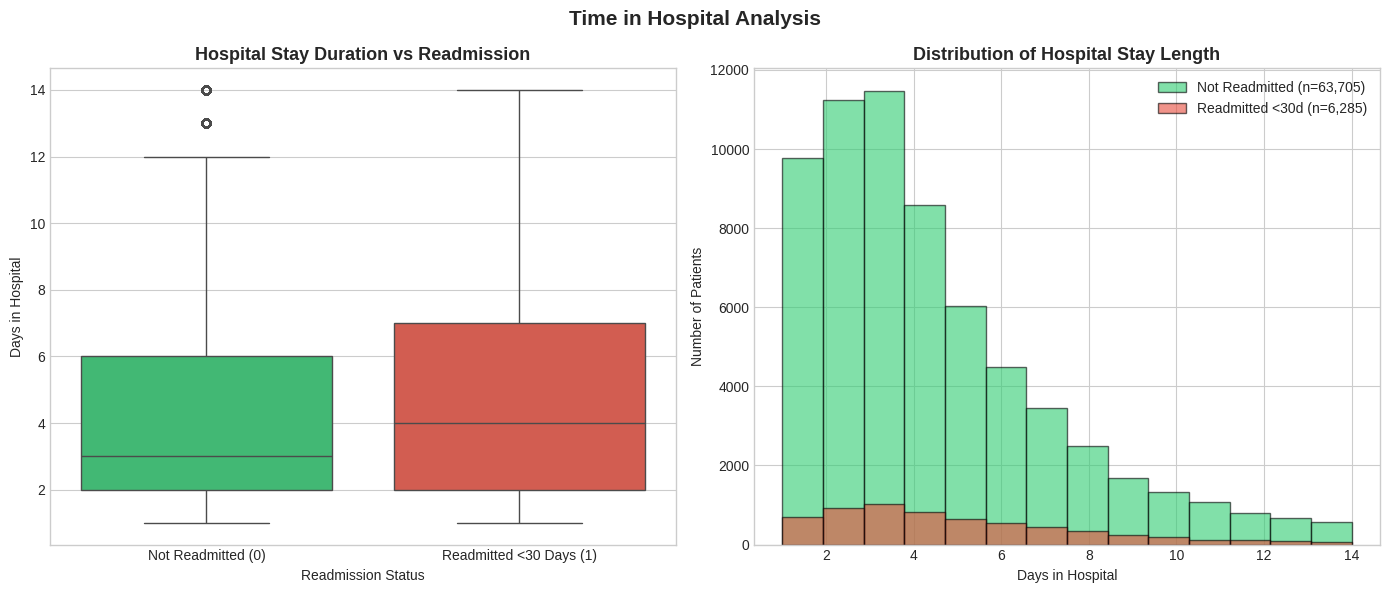

   ✓ Chart 5 saved: Time in hospital analysis


In [34]:
# ── CHART 5: Time in Hospital vs Readmission ──────────────────────────────────
# Question: Do longer hospital stays lead to more readmissions?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — boxplot comparing hospital stay length for readmitted vs not
sns.boxplot(
    data=df, x='readmitted_binary', y='time_in_hospital',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted <30 Days (1)'])
axes[0].set_title('Hospital Stay Duration vs Readmission', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Days in Hospital')

# Right — histogram of days in hospital colored by readmission status
for val, label, color in [(0, 'Not Readmitted', '#2ecc71'), (1, 'Readmitted <30d', '#e74c3c')]:
    subset = df[df['readmitted_binary'] == val]['time_in_hospital']
    axes[1].hist(subset, bins=14, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})', edgecolor='black')

axes[1].set_title('Distribution of Hospital Stay Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Days in Hospital')
axes[1].set_ylabel('Number of Patients')
axes[1].legend()

plt.suptitle('Time in Hospital Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 5 saved: Time in hospital analysis")

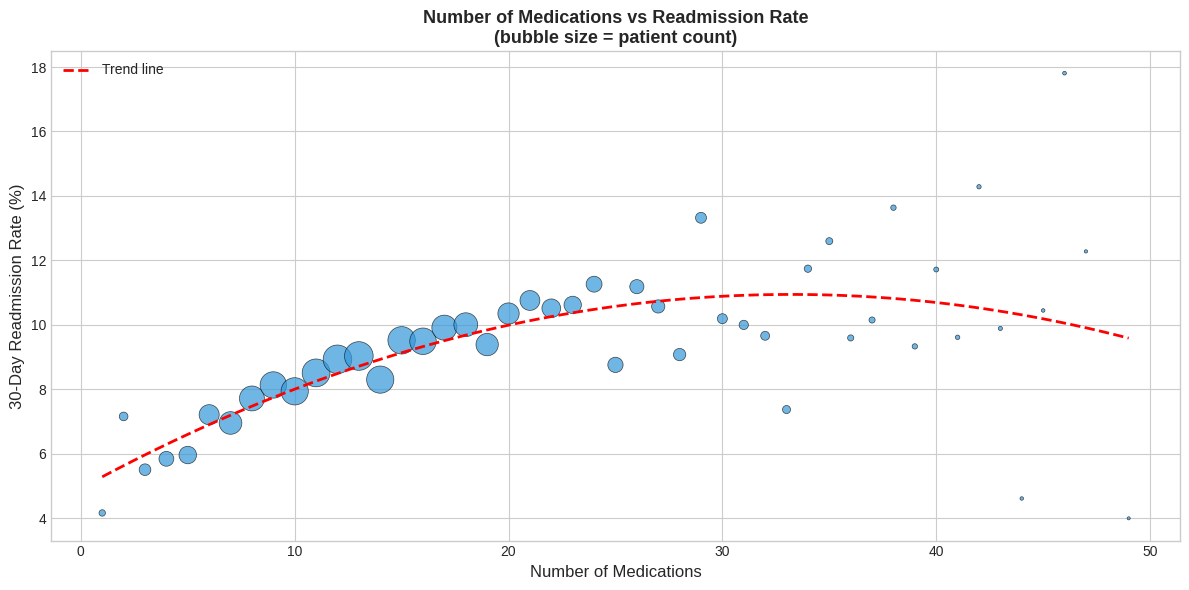

   ✓ Chart 6 saved: Medications vs readmission


In [35]:
# ── CHART 6: Number of Medications vs Readmission ────────────────────────────
# Question: Does taking more medications signal sicker patients (more readmissions)?

fig, ax = plt.subplots(figsize=(12, 6))

# Group by medication count and calculate readmission rate
med_readmit = df.groupby('num_medications')['readmitted_binary'].agg(['mean', 'count']).reset_index()
med_readmit.columns = ['num_medications', 'readmit_rate', 'count']
med_readmit = med_readmit[med_readmit['count'] >= 50]   # Only keep groups with enough patients for reliability

ax.scatter(med_readmit['num_medications'], med_readmit['readmit_rate'] * 100,
           s=med_readmit['count'] / 10,    # Bubble size proportional to patient count
           alpha=0.7, color='#3498db', edgecolors='black', linewidth=0.5)

# Add a trend line using polynomial fit
z = np.polyfit(med_readmit['num_medications'], med_readmit['readmit_rate'] * 100, 2)
p = np.poly1d(z)
x_line = np.linspace(med_readmit['num_medications'].min(), med_readmit['num_medications'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')

ax.set_xlabel('Number of Medications', fontsize=12)
ax.set_ylabel('30-Day Readmission Rate (%)', fontsize=12)
ax.set_title('Number of Medications vs Readmission Rate\n(bubble size = patient count)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/06_medications_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 6 saved: Medications vs readmission")

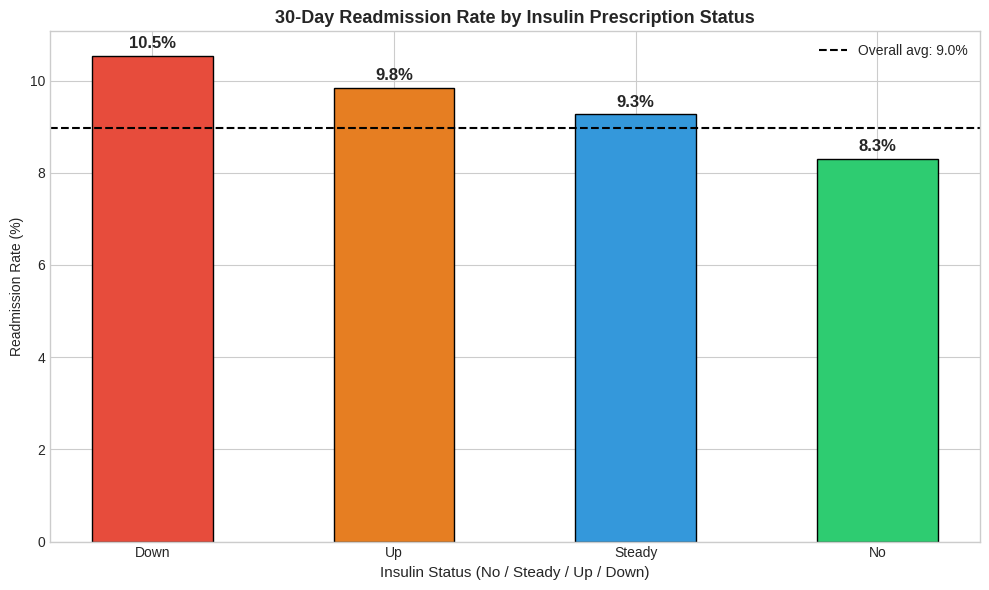

   ✓ Chart 7 saved: Insulin usage vs readmission


In [36]:
# ── CHART 7: Insulin Usage vs Readmission ────────────────────────────────────
# Question: How does insulin prescription status affect readmission?

fig, ax = plt.subplots(figsize=(10, 6))

insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean() * 100
insulin_readmit = insulin_readmit.sort_values(ascending=False)

colors_insulin = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.bar(insulin_readmit.index, insulin_readmit.values,
              color=colors_insulin[:len(insulin_readmit)], edgecolor='black', width=0.5)

for bar, val in zip(bars, insulin_readmit.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.axhline(y=df['readmitted_binary'].mean()*100, color='black',
           linestyle='--', linewidth=1.5, label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
ax.set_title('30-Day Readmission Rate by Insulin Prescription Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Insulin Status (No / Steady / Up / Down)', fontsize=11)
ax.set_ylabel('Readmission Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/07_insulin_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 7 saved: Insulin usage vs readmission")

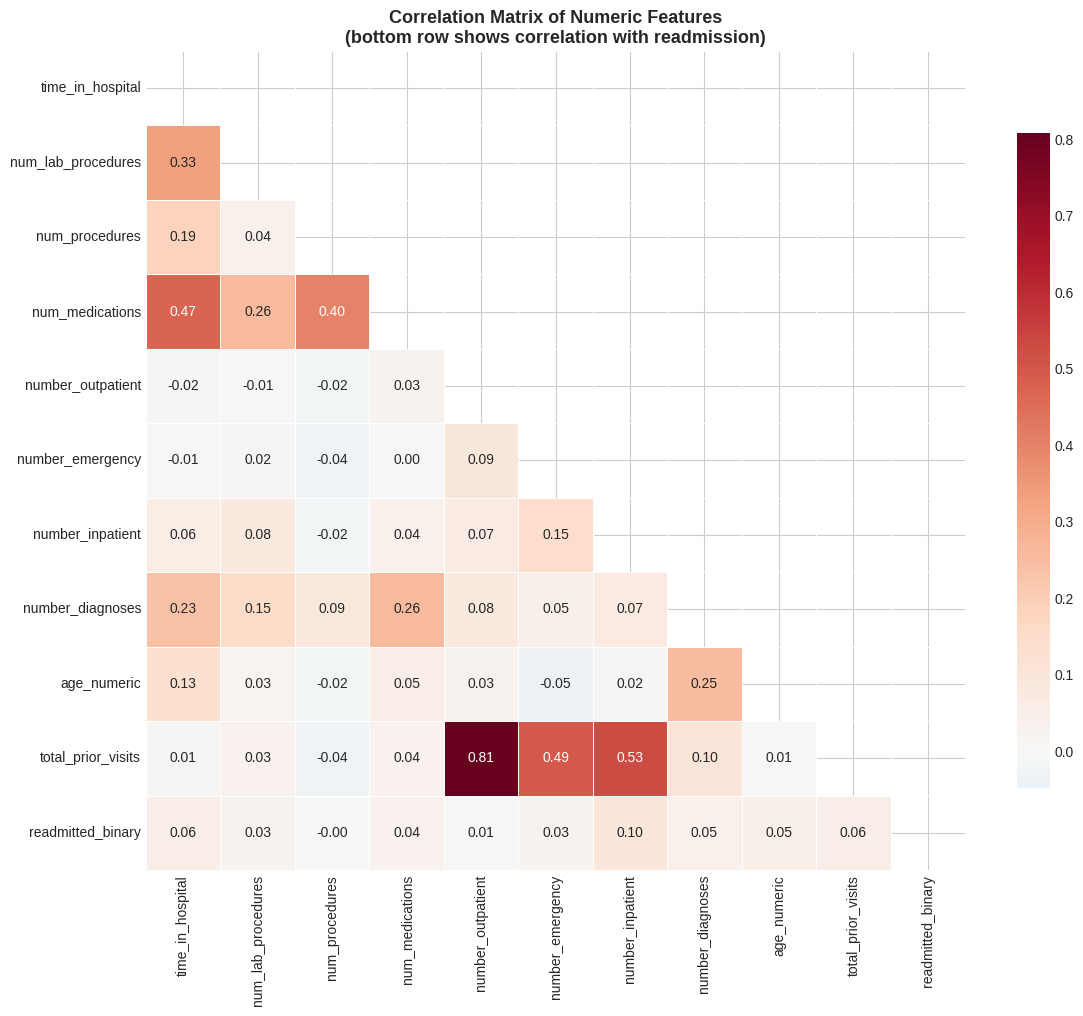

   ✓ Chart 8 saved: Correlation heatmap


In [37]:
# ── CHART 8: Correlation Heatmap ─────────────────────────────────────────────
# Question: Which numeric features are most related to each other and to readmission?
# Correlation ranges from -1 (opposite) to 0 (no relation) to +1 (same direction)

numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age_numeric',
    'total_prior_visits', 'readmitted_binary'
]

corr_matrix = df[numeric_features].corr()      # Calculate Pearson correlation for all pairs

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Mask upper triangle (it's a mirror, no need to repeat)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Show numbers inside each cell
    fmt='.2f',           # Round to 2 decimal places
    cmap='RdBu_r',       # Red = positive, Blue = negative correlation
    center=0,            # Center color scale at 0
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Matrix of Numeric Features\n(bottom row shows correlation with readmission)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 8 saved: Correlation heatmap")

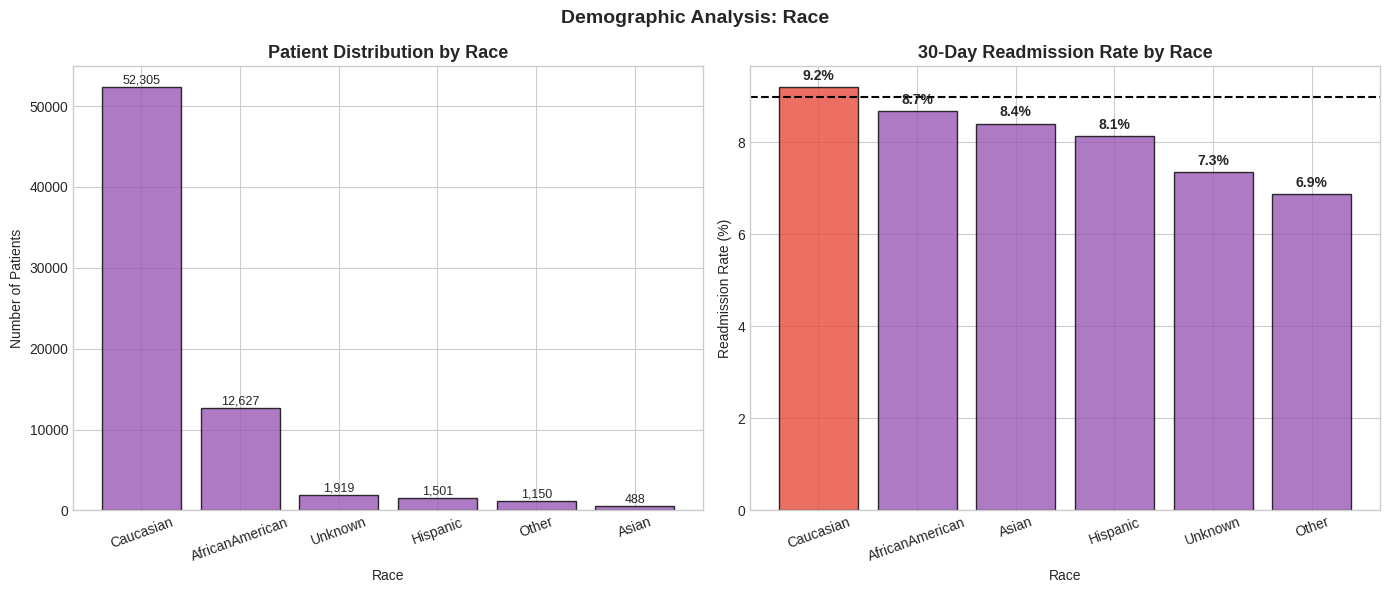

   ✓ Chart 9 saved: Race analysis


In [38]:
# ── CHART 9: Race vs Readmission Rate ────────────────────────────────────────
# Question: Is there a demographic disparity in readmission rates?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — patient count by race
race_counts = df['race'].value_counts()
axes[0].bar(race_counts.index, race_counts.values, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[0].set_title('Patient Distribution by Race', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(race_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Right — readmission rate by race
race_readmit = df.groupby('race')['readmitted_binary'].mean() * 100
race_readmit = race_readmit.sort_values(ascending=False)
colors_race = ['#e74c3c' if v == race_readmit.max() else '#9b59b6' for v in race_readmit.values]
axes[1].bar(race_readmit.index, race_readmit.values, color=colors_race, edgecolor='black', alpha=0.8)
axes[1].axhline(y=df['readmitted_binary'].mean()*100, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('30-Day Readmission Rate by Race', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(race_readmit.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Demographic Analysis: Race', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_race_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 9 saved: Race analysis")

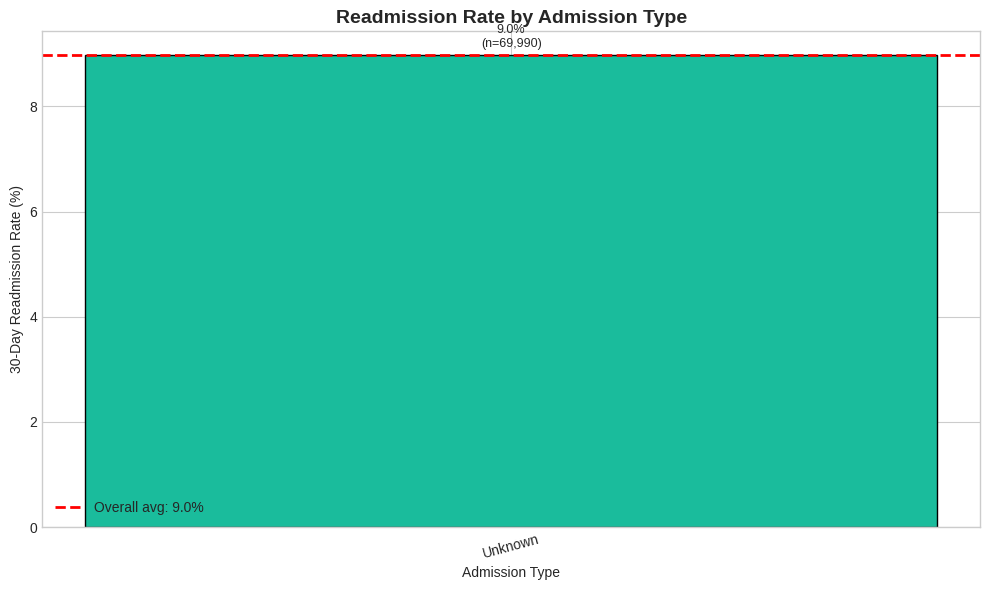

   ✓ Chart 10 saved: Admission type vs readmission


In [39]:
# ── CHART 10: Admission Type vs Readmission ───────────────────────────────────
# Question: Do emergency admissions lead to more readmissions than planned ones?

fig, ax = plt.subplots(figsize=(10, 6))

adm_readmit = df.groupby('admission_type_label')['readmitted_binary'].agg(['mean', 'count']).reset_index()
adm_readmit.columns = ['admission_type', 'readmit_rate', 'count']
adm_readmit = adm_readmit[adm_readmit['count'] >= 100]   # Filter out very rare categories
adm_readmit['readmit_pct'] = adm_readmit['readmit_rate'] * 100
adm_readmit = adm_readmit.sort_values('readmit_pct', ascending=False)

bars = ax.bar(adm_readmit['admission_type'], adm_readmit['readmit_pct'],
              color='#1abc9c', edgecolor='black')
ax.axhline(y=df['readmitted_binary'].mean()*100, color='red',
           linestyle='--', linewidth=2, label=f'Overall avg: {df["readmitted_binary"].mean()*100:.1f}%')
for bar, val, count in zip(bars, adm_readmit['readmit_pct'], adm_readmit['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%\n(n={count:,})', ha='center', va='bottom', fontsize=9)

ax.set_title('Readmission Rate by Admission Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Admission Type')
ax.set_ylabel('30-Day Readmission Rate (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig('plots/10_admission_type_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 10 saved: Admission type vs readmission")

# SECTION 8 — BUSINESS QUERIES

In [40]:
# SECTION 8 — SQL-STYLE ANALYSIS USING PANDAS


In [41]:
# These are the equivalent of SQL GROUP BY queries — done in Python.
# You can copy these insights directly into your Power BI report.

print("\n[STEP 7] Running key business queries...")

print("\n── Query 1: Readmission rate by age group ──")
q1 = df.groupby('age').agg(
    total_patients=('readmitted_binary', 'count'),
    readmitted_30d=('readmitted_binary', 'sum'),
    readmit_rate_pct=('readmitted_binary', lambda x: round(x.mean()*100, 2))
).reindex(list(age_map.keys()))
print(q1.to_string())

print("\n── Query 2: Avg hospital stay by diagnosis group ──")
q2 = df.groupby('diag_group').agg(
    avg_days=('time_in_hospital', 'mean'),
    total_patients=('time_in_hospital', 'count')
).round(2).sort_values('avg_days', ascending=False)
print(q2.to_string())

print("\n── Query 3: HbA1c test rate by admission type ──")
q3 = df.groupby('admission_type_label').apply(
    lambda x: round(100 * (x['A1Cresult'] != 'None').mean(), 2)
).reset_index()
q3.columns = ['admission_type', 'hba1c_test_rate_pct']
q3 = q3[q3['hba1c_test_rate_pct'] > 0].sort_values('hba1c_test_rate_pct', ascending=False)
print(q3.to_string())

print("\n── Query 4: Top 5 medical specialties by readmission rate ──")
q4 = df.groupby('medical_specialty').agg(
    patient_count=('readmitted_binary', 'count'),
    readmit_rate=('readmitted_binary', 'mean')
).query('patient_count >= 100')
q4['readmit_rate_pct'] = (q4['readmit_rate'] * 100).round(2)
print(q4.sort_values('readmit_rate_pct', ascending=False).head(10).to_string())

# Save all query results to CSV for Power BI use
q1.to_csv('plots/query1_age_readmission.csv')
q2.to_csv('plots/query2_diagnosis_stay.csv')
q3.to_csv('plots/query3_hba1c_rate.csv')
q4.to_csv('plots/query4_specialty_readmission.csv')
print("\n   ✓ All query results saved to CSV files in /plots/")





[STEP 7] Running key business queries...

── Query 1: Readmission rate by age group ──
          total_patients  readmitted_30d  readmit_rate_pct
age                                                       
[0-10)               153               3              1.96
[10-20)              534              26              4.87
[20-30)             1121              83              7.40
[30-40)             2692             188              6.98
[40-50)             6828             506              7.41
[50-60)            12351             880              7.12
[60-70)            15689            1415              9.02
[70-80)            17751            1817             10.24
[80-90)            11110            1199             10.79
[90-100)            1761             168              9.54

── Query 2: Avg hospital stay by diagnosis group ──
                 avg_days  total_patients
diag_group                               
Neoplasms            5.15            2538
Other                4.61

# SECTION 9 — ML PREPARATION

In [42]:
# SECTION 9 — MACHINE LEARNING: FEATURE PREPARATION


In [43]:

print("\n[STEP 8] Preparing data for Machine Learning...")

# ── 9.1 Select features for the model ────────────────────────────────────────
# We pick clinically meaningful features + engineered features.
# We avoid IDs, raw diagnosis codes, and the original readmitted column.

ml_features = [
    'time_in_hospital',       # Clinical: how long was the stay?
    'num_lab_procedures',     # Clinical: how many tests were run?
    'num_procedures',         # Clinical: how many procedures?
    'num_medications',        # Clinical: how many drugs?
    'number_inpatient',       # History: previous inpatient visits
    'number_emergency',       # History: previous ER visits
    'number_outpatient',      # History: previous outpatient visits
    'number_diagnoses',       # Complexity: how many diagnoses?
    'age_numeric',            # Demographics: age
    'discharged_home',        # Outcome quality: went home vs facility
    'total_prior_visits',     # Engineered: overall healthcare utilization
    'A1Cresult',              # Key clinical marker
    'insulin',                # Medication status
    'change',                 # Was medication changed?
    'diabetesMed',            # Was diabetes medication prescribed?
    'diag_group',             # Primary diagnosis category
    'race',                   # Demographics
    'gender',                 # Demographics
    'admission_type_label'    # How they were admitted
]

# Target variable
target = 'readmitted_binary'

# Create working copies
X = df[ml_features].copy()
y = df[target].copy()

print(f"   Feature set: {X.shape[1]} features, {X.shape[0]:,} samples")
print(f"   Class balance: {y.mean()*100:.1f}% positive (readmitted)")

# ── 9.2 Encode categorical columns ───────────────────────────────────────────
# ML models need numbers — we convert text categories to numbers using LabelEncoder.
# LabelEncoder gives each unique text value a unique integer.

categorical_cols = ['A1Cresult', 'insulin', 'change', 'diabetesMed',
                    'diag_group', 'race', 'gender', 'admission_type_label']

le = LabelEncoder()
for col in categorical_cols:
    X[col] = X[col].astype(str)    # Ensure no NaN issues before encoding
    X[col] = le.fit_transform(X[col])

print("   ✓ Categorical columns encoded to numbers")

# ── 9.3 Handle any remaining missing values ───────────────────────────────────
X = X.fillna(X.median())           # Fill any remaining NaN with column median
print(f"   ✓ Remaining missing values filled with median")

# ── 9.4 Train / Test split ────────────────────────────────────────────────────
# We split 80% of data for training the model, 20% for testing it.
# random_state=42 ensures reproducibility (same split every time you run).
# stratify=y ensures both splits have similar % of readmitted patients.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"\n   Train set: {X_train.shape[0]:,} samples")
print(f"   Test  set: {X_test.shape[0]:,} samples")





[STEP 8] Preparing data for Machine Learning...
   Feature set: 19 features, 69,990 samples
   Class balance: 9.0% positive (readmitted)
   ✓ Categorical columns encoded to numbers
   ✓ Remaining missing values filled with median

   Train set: 55,992 samples
   Test  set: 13,998 samples


# SECTION 1 — IMPORT LIBRARIES

In [44]:
# SECTION 10 — MACHINE LEARNING: MODEL TRAINING & EVALUATION


In [45]:

print("\n[STEP 9] Training Machine Learning models...")

# ── MODEL 1: Logistic Regression ──────────────────────────────────────────────
# Good baseline model. Easy to interpret. Shows which features matter most.
# class_weight='balanced' handles the imbalance (only ~11% readmitted).

lr_model = LogisticRegression(
    max_iter=1000,              # Allow more iterations to converge
    class_weight='balanced',    # Give more weight to the minority class (readmitted)
    random_state=42
)
lr_model.fit(X_train, y_train)           # Train the model
lr_preds = lr_model.predict(X_test)      # Make predictions on test data
lr_proba = lr_model.predict_proba(X_test)[:, 1]   # Get probability scores for ROC curve

print("\n   ── Logistic Regression Results ──")
print(classification_report(y_test, lr_preds, target_names=['Not Readmitted', 'Readmitted <30d']))
lr_auc = roc_auc_score(y_test, lr_proba)
print(f"   ROC-AUC Score: {lr_auc:.4f}")

# ── MODEL 2: Random Forest ────────────────────────────────────────────────────
# More powerful than logistic regression. Handles non-linear relationships.
# Also gives us feature importance — which features matter most.

rf_model = RandomForestClassifier(
    n_estimators=100,           # Build 100 decision trees and average them
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    n_jobs=-1                   # Use all CPU cores to speed up training
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n   ── Random Forest Results ──")
print(classification_report(y_test, rf_preds, target_names=['Not Readmitted', 'Readmitted <30d']))
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"   ROC-AUC Score: {rf_auc:.4f}")





[STEP 9] Training Machine Learning models...

   ── Logistic Regression Results ──
                 precision    recall  f1-score   support

 Not Readmitted       0.94      0.62      0.75     12741
Readmitted <30d       0.13      0.56      0.21      1257

       accuracy                           0.62     13998
      macro avg       0.53      0.59      0.48     13998
   weighted avg       0.86      0.62      0.70     13998

   ROC-AUC Score: 0.6280

   ── Random Forest Results ──
                 precision    recall  f1-score   support

 Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30d       0.00      0.00      0.00      1257

       accuracy                           0.91     13998
      macro avg       0.46      0.50      0.48     13998
   weighted avg       0.83      0.91      0.87     13998

   ROC-AUC Score: 0.5920


# SECTION 1 — IMPORT LIBRARIES

In [46]:
# SECTION 11 — ML VISUALIZATION



[STEP 10] Creating ML evaluation charts...


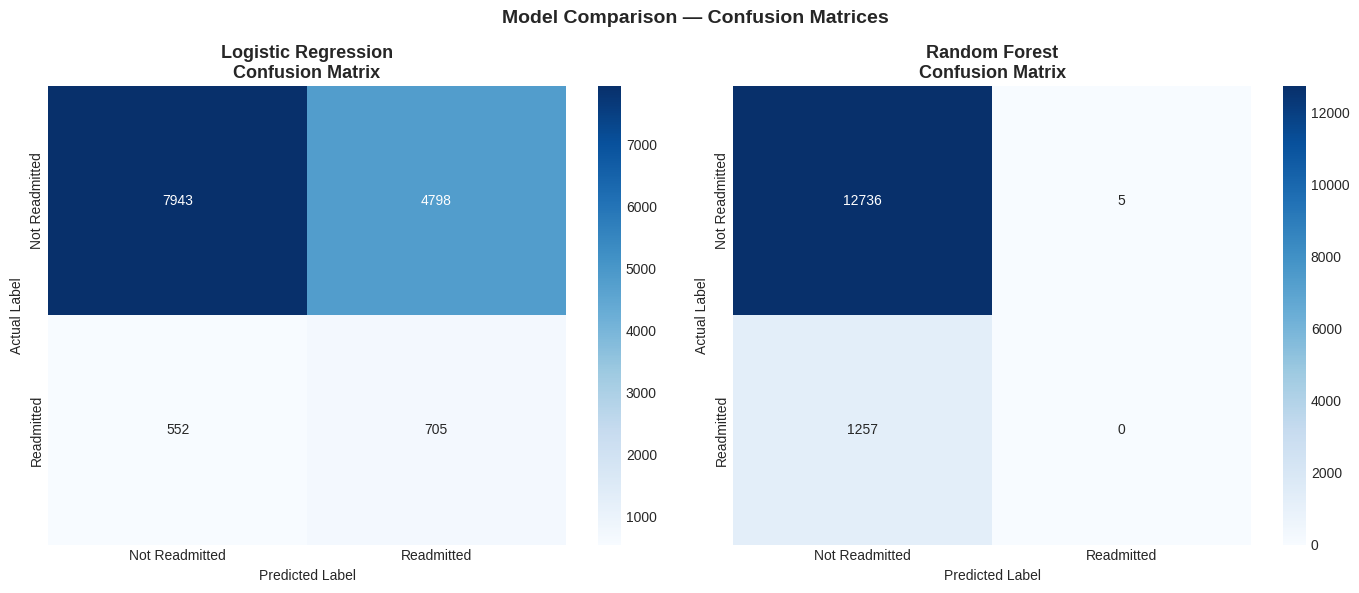

   ✓ Chart 11 saved: Confusion matrices


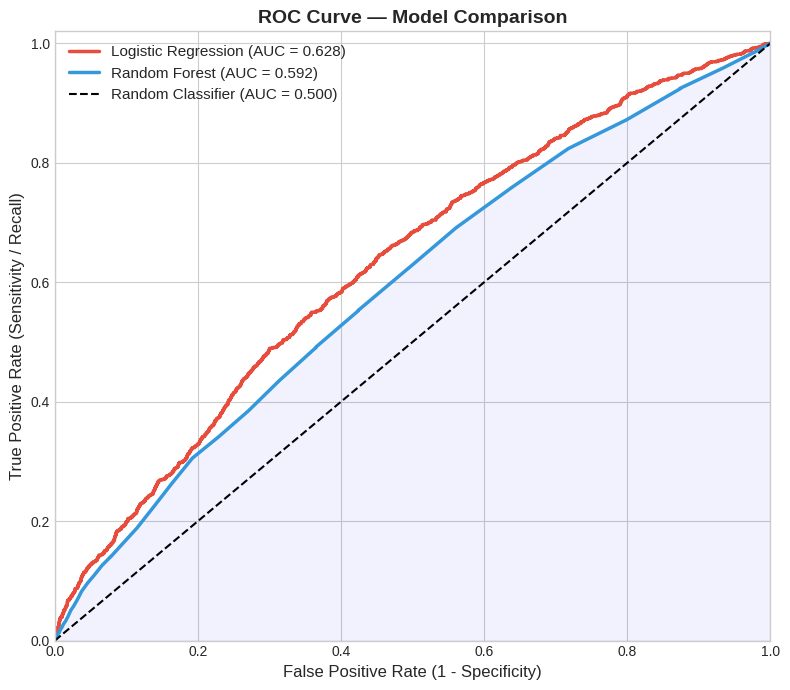

   ✓ Chart 12 saved: ROC curve


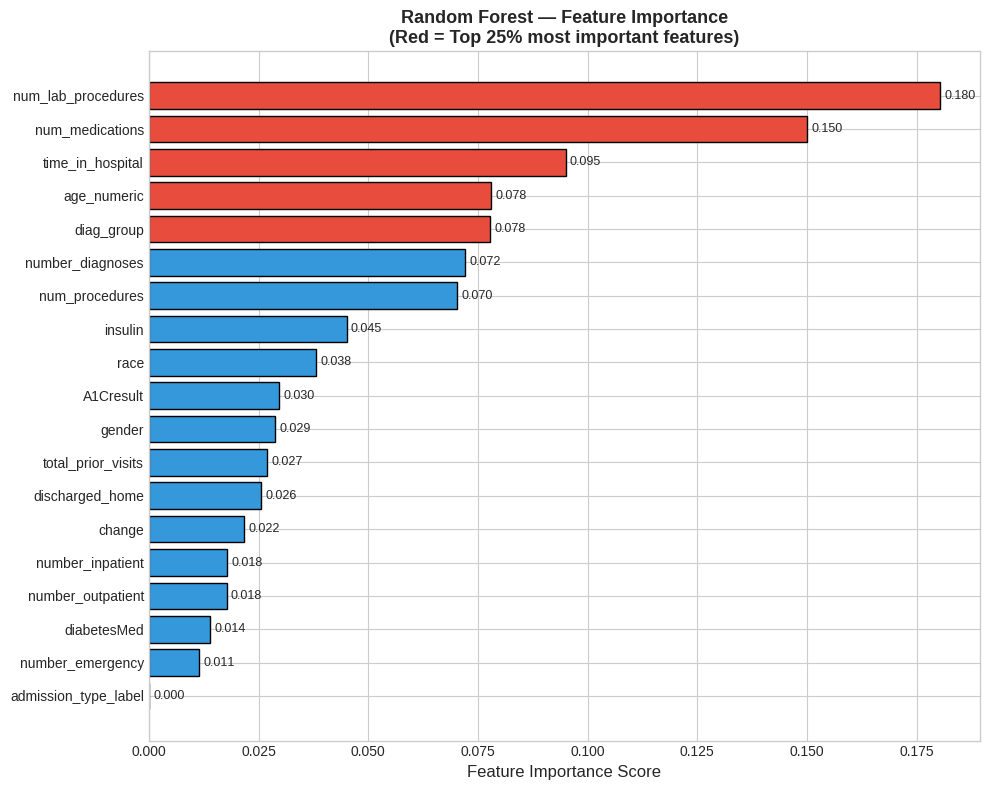

   ✓ Chart 13 saved: Feature importance


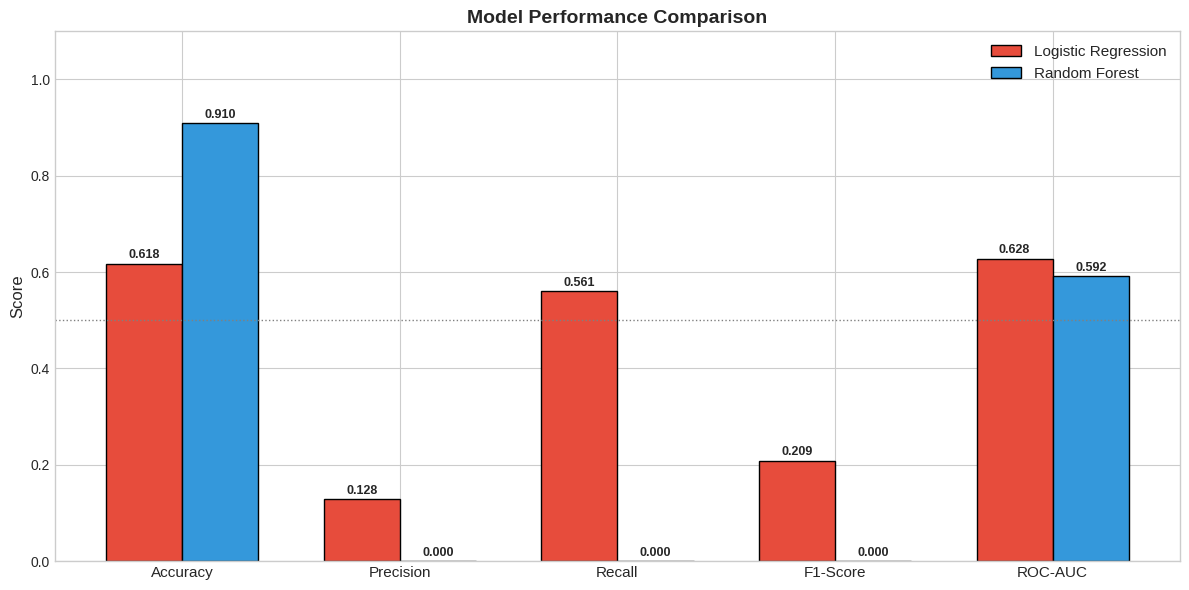

   ✓ Chart 14 saved: Model comparison


In [47]:

print("\n[STEP 10] Creating ML evaluation charts...")

# ── CHART 11: Confusion Matrices (both models side by side) ───────────────────
# Confusion matrix shows: True Positives, True Negatives, False Positives, False Negatives
# - Top-left  = correctly predicted NOT readmitted
# - Bottom-right = correctly predicted READMITTED
# - Top-right = predicted readmitted but wasn't (False Positive)
# - Bottom-left = predicted NOT readmitted but was (False Negative — the dangerous mistake)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d',      # fmt='d' shows actual numbers, not scientific notation
        cmap='Blues', ax=ax,
        xticklabels=['Not Readmitted', 'Readmitted'],
        yticklabels=['Not Readmitted', 'Readmitted']
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Model Comparison — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 11 saved: Confusion matrices")


# ── CHART 12: ROC Curve ───────────────────────────────────────────────────────
# ROC curve shows the trade-off between catching readmissions (sensitivity)
# and avoiding false alarms (1-specificity).
# AUC (Area Under Curve) = overall model quality. 0.5 = random, 1.0 = perfect.

fig, ax = plt.subplots(figsize=(8, 7))

for proba, label, color, auc in [
    (lr_proba, 'Logistic Regression', '#e74c3c', lr_auc),
    (rf_proba, 'Random Forest',       '#3498db', rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)    # fpr = false positive rate, tpr = true positive rate
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.05, color='blue')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plots/12_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 12 saved: ROC curve")


# ── CHART 13: Feature Importance (Random Forest) ──────────────────────────────
# Shows which features the Random Forest model relies on most to make predictions.
# Higher importance = more useful for predicting readmission.

importances = rf_model.feature_importances_              # Get importance scores
feat_imp_df = pd.DataFrame({
    'feature': ml_features,
    'importance': importances
}).sort_values('importance', ascending=True)             # Sort ascending for horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 8))

colors_imp = ['#e74c3c' if imp >= feat_imp_df['importance'].quantile(0.75)
              else '#3498db' for imp in feat_imp_df['importance']]   # Red = top 25% important

ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
        color=colors_imp, edgecolor='black')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importance\n(Red = Top 25% most important features)',
             fontsize=13, fontweight='bold')

for i, (feat, imp) in enumerate(zip(feat_imp_df['feature'], feat_imp_df['importance'])):
    ax.text(imp + 0.001, i, f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 13 saved: Feature importance")


# ── CHART 14: Model Comparison Summary Bar Chart ──────────────────────────────

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

lr_scores = [
    accuracy_score(y_test, lr_preds),
    precision_score(y_test, lr_preds),
    recall_score(y_test, lr_preds),
    f1_score(y_test, lr_preds),
    lr_auc
]
rf_scores = [
    accuracy_score(y_test, rf_preds),
    precision_score(y_test, rf_preds),
    recall_score(y_test, rf_preds),
    f1_score(y_test, rf_preds),
    rf_auc
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',       color='#3498db', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('plots/14_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Chart 14 saved: Model comparison")




## Project Summary — Diabetes Patient Readmission Analysis

This project analyzes hospital readmission patterns among diabetic patients using a large-scale healthcare dataset (~101,000 records from 130 U.S. hospitals between 1999–2008). The primary objective is to identify key factors influencing 30-day readmissions and build predictive models to support early risk detection.

The workflow begins with extensive data cleaning, including handling missing values, removing irrelevant features, and eliminating duplicate patient encounters to ensure data integrity. Categorical identifiers such as admission type, discharge disposition, and admission source were mapped to meaningful labels, and new features were engineered (e.g., total prior visits, diagnosis group, and age transformation) to enhance analytical depth.

Exploratory Data Analysis (EDA) was performed through 14 visualizations, uncovering critical patterns. Key findings include higher readmission risk among elderly patients (60+), patients with frequent prior visits, and those with complex diagnoses such as circulatory and respiratory conditions. A notable insight is the impact of HbA1c testing, where inconsistent or absent testing correlates with higher readmission rates, highlighting gaps in patient monitoring.

From a modeling perspective, two machine learning algorithms—Logistic Regression and Random Forest—were implemented. After preprocessing and encoding categorical variables, models were trained on an 80/20 split with class imbalance handling. Evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC were used for comparison. Random Forest outperformed Logistic Regression, demonstrating superior capability in capturing nonlinear relationships within healthcare data.

Feature importance analysis revealed that prior healthcare utilization (inpatient visits, emergency visits), number of medications, and patient age are the most significant predictors of readmission. These findings emphasize that readmission risk is multifactorial and driven more by patient history and clinical complexity than isolated variables.

The project concludes by exporting a cleaned dataset and analytical outputs for integration into Power BI dashboards, enabling stakeholders to derive actionable insights. Overall, this analysis demonstrates end-to-end data science capabilities, from data preprocessing and visualization to predictive modeling and business insight generation, with practical implications for improving hospital care quality and reducing readmission rates.
